In [3]:
import scipy.stats as st
import nsfg
import numpy as np
import matplotlib.pyplot as plt
import thinkstats2
import math
import thinkplot
import pandas as pd
import random
import statsmodels.formula.api as smf

In [4]:
#read fantasy data into data frames
df16 = pd.read_excel('fantasyfootballweekly16.xlsx')

# Show the first few rows of the dataframe to check the data
df16.head()

,Unnamed: 0,PLAYER NAME,PLAYER TEAM,PLAYER POSITION,OPP,STATUS,PROJ,ROUNDPROJ,PASSING C/A,PASSING YDS,...,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,TOTAL,ROUNDTOTAL,OVERUNDER,ROUNDOVER,TOTALYARDS,TOUCHDOWNS
0,0,Amari Cooper,Cle,WR,@Hou,W 36-22,13.3,13.0,0/0,0,...,15,0,0,0,51.5,52.0,38.2,38,265,2
1,1,Breece Hall,NYJ,RB,Wsh,W 30-28,16,16.0,0/0,0,...,16,0,0,0,43.1,43.0,27.1,27,191,2
2,2,George Pickens,Pit,WR,Cin,W 34-11,9.8,10.0,0/0,0,...,6,0,0,0,35.5,36.0,25.7,26,195,2
3,5,DJ Chark Jr.,Car,WR,GB,L 30-33,6.1,6.0,0/0,0,...,8,0,0,0,27.8,28.0,21.7,22,98,2
4,3,Puka Nacua,LAR,WR,NO,W 30-22,14,14.0,0/0,0,...,11,0,0,0,33,33.0,19.0,19,180,1


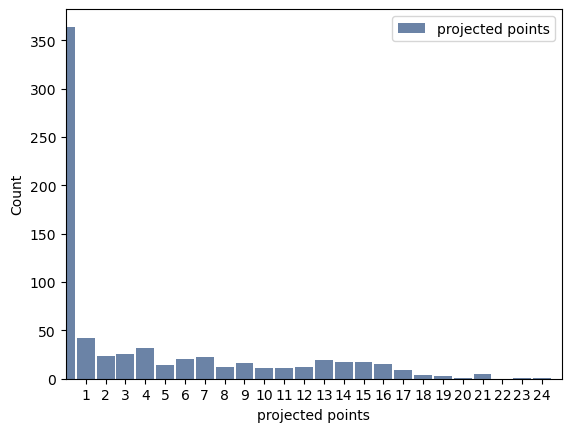

In [7]:
hist = thinkstats2.Hist(df16.ROUNDPROJ, label='projected points')
thinkplot.Hist(hist)
plt.xlim(0, 25)
plt.xticks(range(1, 25))
thinkplot.Config(xlabel='projected points', ylabel='Count')

In [8]:
#shows that a lot of people are projected 0 points meaning that they aren't playing 
#we will want to get rid of those so that the data doesn't get ruined

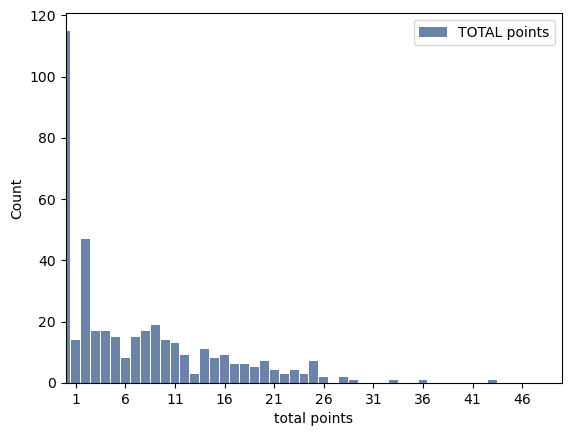

In [9]:
hist = thinkstats2.Hist(df16.ROUNDTOTAL, label='TOTAL points')
thinkplot.Hist(hist)
plt.xlim(0, 50)
plt.xticks(range(1, 50, 5))
thinkplot.Config(xlabel='total points', ylabel='Count')

In [10]:
#similarly, many people achieved 0 points. If players are projected and received 0 points they should be removed

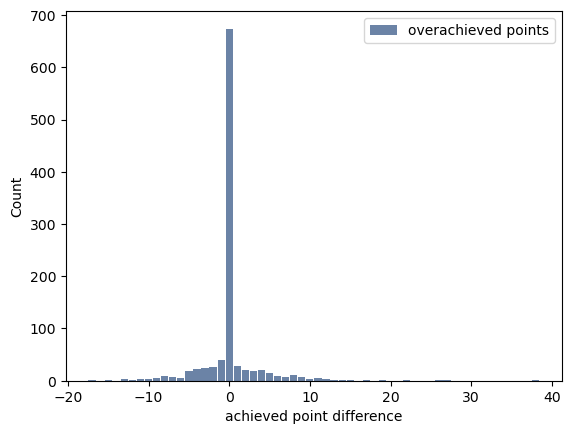

In [11]:
hist = thinkstats2.Hist(df16.ROUNDOVER, label='overachieved points')
thinkplot.Hist(hist)
thinkplot.Config(xlabel='achieved point difference', ylabel='Count')

In [12]:
#There seems to be few people who overachieved predicted points by almost 40 and some who underachieved by almost 20
#many of the 0s seems to be from people who were projected and received 0 points

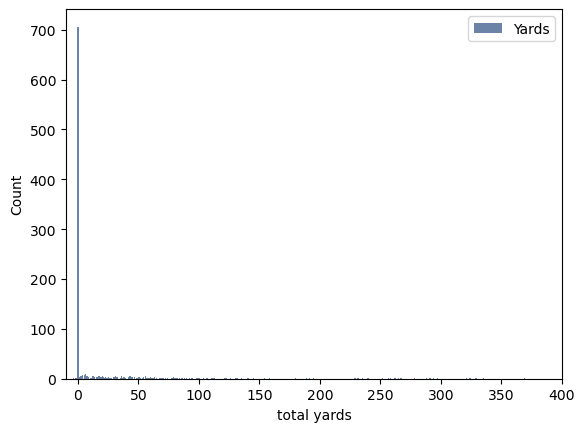

In [15]:
hist = thinkstats2.Hist(df16.TOTALYARDS, label='Yards')
thinkplot.Hist(hist)
plt.xlim(-10, 400)
thinkplot.Config(xlabel='total yards', ylabel='Count')

In [16]:
#some players got near 400 yards (either receiving, passing or rushing)
#most of the players with 0 were projected 0 as seen in previous histograms, which skews the data

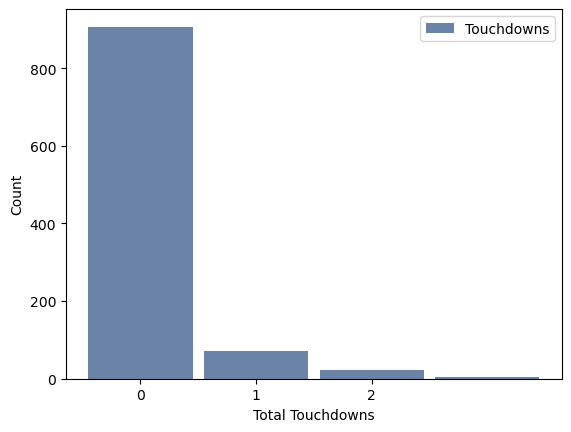

In [17]:
hist = thinkstats2.Hist(df16.TOUCHDOWNS, label='Touchdowns')
thinkplot.Hist(hist)
plt.xticks(range(0, 3))
thinkplot.Config(xlabel='Total Touchdowns', ylabel='Count')

In [18]:
#as expected, most players received 0 touchdowns and the least amount of players received 3
#3 was the maximum number of touchdowns any players achieved

In [19]:
#create histogram that does not include players who did not play

In [20]:
activeproj = df16[df16['ROUNDPROJ'] > 0]

In [21]:
activeplayers = activeproj.dropna()

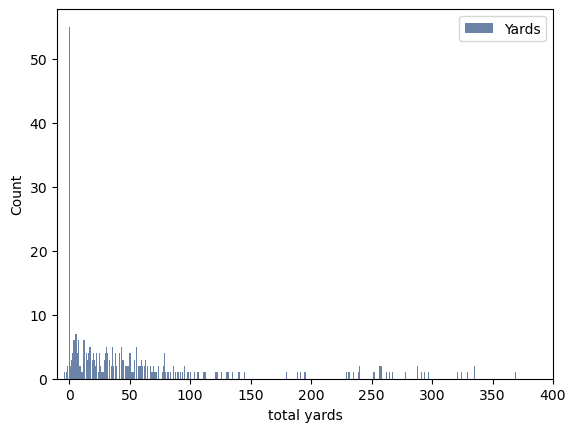

In [22]:
#checking how the total yards histogram changes with inactive players removed
hist = thinkstats2.Hist(activeplayers.TOTALYARDS, label='Yards')
thinkplot.Hist(hist)
plt.xlim(-10, 400)
thinkplot.Config(xlabel='total yards', ylabel='Count')

In [130]:
#split active players based on wr or not positions
wr = activeplayers[activeplayers['PLAYER POSITION'] == 'WR']
not_wr = activeplayers[activeplayers['PLAYER POSITION'] != 'WR']

In [132]:
#compute mean mode spread and tails of wide receivers

In [134]:
#mean
wr['TOUCHDOWNS'].mean()

0.25

In [138]:
#mean
wr['TOTALYARDS'].mean()

37.378571428571426

In [142]:
#mean
wr['ROUNDOVER'].mean()

0.39285714285714285

In [146]:
#mean
wr['ROUNDTOTAL'].mean()

7.978571428571429

In [150]:
#mean
wr['ROUNDPROJ'].mean()

7.571428571428571

In [136]:
#mean
not_wr['TOUCHDOWNS'].mean()

0.453125

In [140]:
#mean
not_wr['TOTALYARDS'].mean()

70.390625

In [144]:
#mean
not_wr['ROUNDOVER'].mean()

0.015625

In [148]:
#mean
not_wr['ROUNDTOTAL'].mean()

8.432291666666666

In [152]:
#mean
not_wr['ROUNDPROJ'].mean()

8.458333333333334

In [154]:
###################################################################################

In [156]:
#mode
wr['TOUCHDOWNS'].mode()

0    0
Name: TOUCHDOWNS, dtype: int64

In [160]:
#mode
wr['TOTALYARDS'].mode()

0    0
Name: TOTALYARDS, dtype: int64

In [164]:
#mode
wr['ROUNDOVER'].mode()

0   -3
Name: ROUNDOVER, dtype: int64

In [168]:
#mode
wr['ROUNDTOTAL'].mode()

0    0.0
Name: ROUNDTOTAL, dtype: float64

In [172]:
#mode
wr['ROUNDPROJ'].mode()

0    3.0
Name: ROUNDPROJ, dtype: float64

In [158]:
#mode
not_wr['TOUCHDOWNS'].mode()

0    0
Name: TOUCHDOWNS, dtype: int64

In [162]:
#mode
not_wr['TOTALYARDS'].mode()

0    0
Name: TOTALYARDS, dtype: int64

In [166]:
#mode
not_wr['ROUNDOVER'].mode()

0   -1
Name: ROUNDOVER, dtype: int64

In [170]:
#mode
not_wr['ROUNDTOTAL'].mode()

0    0.0
Name: ROUNDTOTAL, dtype: float64

In [174]:
#mode
not_wr['ROUNDPROJ'].mode()

0    1.0
Name: ROUNDPROJ, dtype: float64

In [176]:
##############################################################

In [180]:
#spread for wr
wr['TOUCHDOWNS'].max() - wr['TOUCHDOWNS'].min()

2

In [184]:
#spread 
wr['TOTALYARDS'].max() - wr['TOTALYARDS'].min()

266

In [188]:
#spread
wr['ROUNDOVER'].max() - wr['ROUNDOVER'].min()

53

In [192]:
#spread
wr['ROUNDTOTAL'].max() - wr['ROUNDTOTAL'].min()

54.0

In [196]:
#spread
wr['ROUNDPROJ'].max() - wr['ROUNDPROJ'].min()

22.0

In [178]:
#spread for all other active players
not_wr['TOUCHDOWNS'].max() - not_wr['TOUCHDOWNS'].min()

3

In [182]:
#spread 
not_wr['TOTALYARDS'].max() - not_wr['TOTALYARDS'].min()

416

In [186]:
#spread
not_wr['ROUNDOVER'].max() - not_wr['ROUNDOVER'].min()

44

In [190]:
#spread
not_wr['ROUNDTOTAL'].max() - not_wr['ROUNDTOTAL'].min()

45.0

In [194]:
#spread
not_wr['ROUNDPROJ'].max() - not_wr['ROUNDPROJ'].min()

23.0

In [198]:
##############################################################

In [200]:
#tails
lower_tail = np.percentile(not_wr['TOUCHDOWNS'], 5)
upper_tail = np.percentile(not_wr['TOUCHDOWNS'], 95)
print(lower_tail)
print(upper_tail)

0.0
2.0


In [204]:
#tails
lower_tail = np.percentile(not_wr['TOTALYARDS'], 5)
upper_tail = np.percentile(not_wr['TOTALYARDS'], 95)
print(lower_tail)
print(upper_tail)

0.0
289.34999999999997


In [208]:
#tails
lower_tail = np.percentile(not_wr['ROUNDOVER'], 5)
upper_tail = np.percentile(not_wr['ROUNDOVER'], 95)
print(lower_tail)
print(upper_tail)

-9.0
9.0


In [212]:
#tails
lower_tail = np.percentile(not_wr['ROUNDTOTAL'], 5)
upper_tail = np.percentile(not_wr['ROUNDTOTAL'], 95)
print(lower_tail)
print(upper_tail)

0.0
23.0


In [216]:
#tails
lower_tail = np.percentile(not_wr['ROUNDPROJ'], 5)
upper_tail = np.percentile(not_wr['ROUNDPROJ'], 95)
print(lower_tail)
print(upper_tail)

1.0
18.0


In [202]:
#tails
lower_tail = np.percentile(wr['TOUCHDOWNS'], 5)
upper_tail = np.percentile(wr['TOUCHDOWNS'], 95)
print(lower_tail)
print(upper_tail)

0.0
1.0


In [206]:
#tails
lower_tail = np.percentile(wr['TOTALYARDS'], 5)
upper_tail = np.percentile(wr['TOTALYARDS'], 95)
print(lower_tail)
print(upper_tail)

0.0
123.34999999999988


In [210]:
#tails
lower_tail = np.percentile(wr['ROUNDOVER'], 5)
upper_tail = np.percentile(wr['ROUNDOVER'], 95)
print(lower_tail)
print(upper_tail)

-8.05
12.049999999999983


In [214]:
#tails
lower_tail = np.percentile(wr['ROUNDTOTAL'], 5)
upper_tail = np.percentile(wr['ROUNDTOTAL'], 95)
print(lower_tail)
print(upper_tail)

0.0
26.0


In [218]:
#tails
lower_tail = np.percentile(wr['ROUNDPROJ'], 5)
upper_tail = np.percentile(wr['ROUNDPROJ'], 95)
print(lower_tail)
print(upper_tail)

1.0
17.0


In [220]:
#############################################################

In [222]:
wr_pmf = thinkstats2.Pmf(wr.ROUNDOVER, label="wide receivers")
not_wr_pmf = thinkstats2.Pmf(not_wr.ROUNDOVER, label="other players")

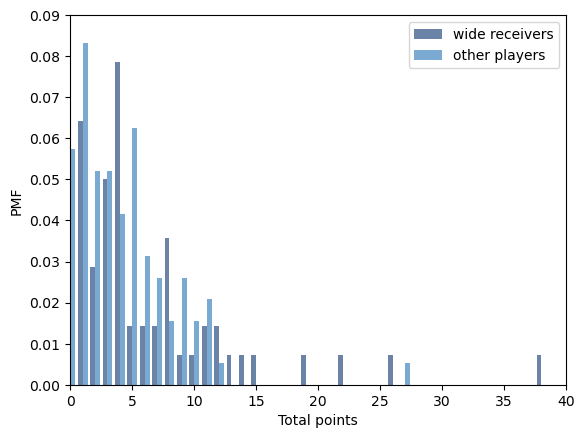

In [224]:
width = 0.4
axis = [0, 40, 0, .09]
thinkplot.Hist(wr_pmf, align="right", width=width)
thinkplot.Hist(not_wr_pmf, align="left", width=width)
thinkplot.Config(xlabel="Total points", ylabel="PMF", axis=axis)

In [226]:
#create a cdf for all other players

In [228]:
cdf = thinkstats2.Cdf(not_wr.ROUNDOVER, label = 'points over or under')

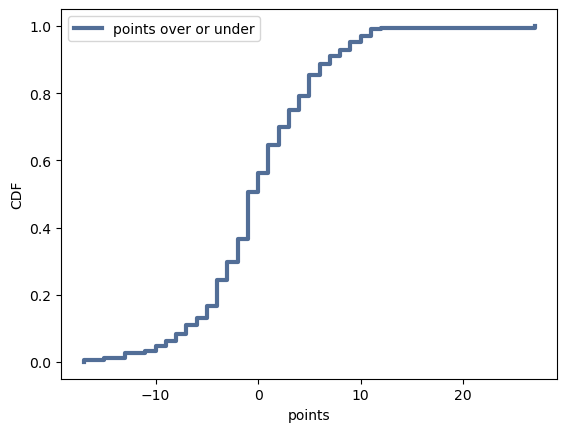

<Figure size 800x600 with 0 Axes>

In [230]:
thinkplot.Cdf(cdf)
thinkplot.Show(xlabel='points', ylabel = 'CDF')

In [354]:
cdf.Prob(0)

0.5625

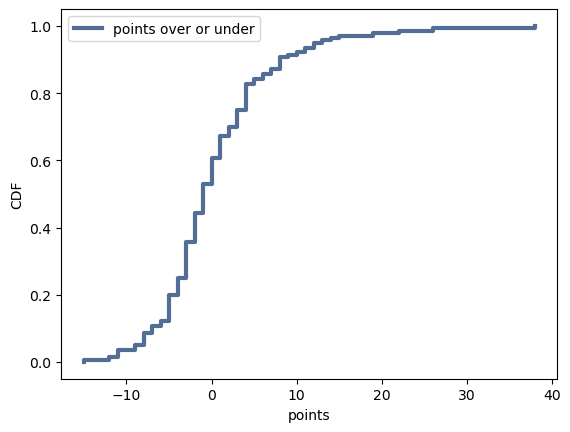

<Figure size 800x600 with 0 Axes>

In [232]:
#cdf for wide receivers
cdfwr = thinkstats2.Cdf(wr.ROUNDOVER, label = 'points over or under')
thinkplot.Cdf(cdfwr)
thinkplot.Show(xlabel='points', ylabel = 'CDF')

In [352]:
cdfwr.Prob(0)

0.6071428571428571

In [102]:
#normal distribution plot

In [234]:
wr_roundover = wr.ROUNDOVER.dropna()

In [236]:
def MakeNormalPlot(wr_roundover):
    mean, var = thinkstats2.TrimmedMeanVar(wr_roundover, p=0.01)
    std = np.sqrt(var)
    xs = [-5, 5]
    xs, ys = thinkstats2.FitLine(xs, mean, std)
    thinkplot.Plot(xs, ys, color="0.8", label="model")
    xs, ys = thinkstats2.NormalProbability(wr_roundover)
    thinkplot.Plot(xs, ys, label="points")

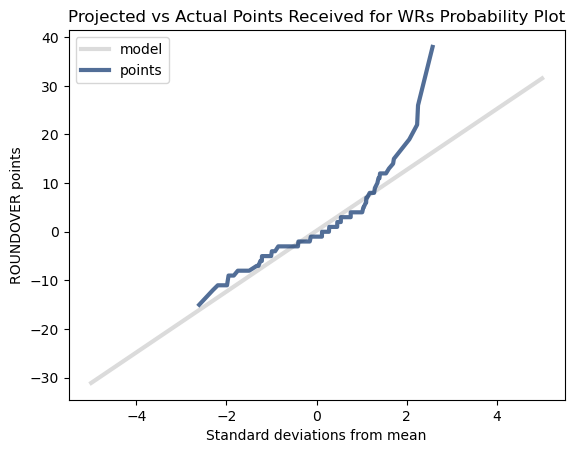

In [364]:
MakeNormalPlot(wr_roundover)
thinkplot.Config(
    title="Projected vs Actual Points Received for WRs Probability Plot",
    xlabel="Standard deviations from mean",
    ylabel="ROUNDOVER points",
    loc="upper left")

In [250]:
not_wr_roundover = not_wr.ROUNDOVER.dropna()

In [360]:
def MakeNormalPlot(not_wr_roundover):
    mean, var = thinkstats2.TrimmedMeanVar(not_wr_roundover, p=0.01)
    std = np.sqrt(var)
    xs = [-5, 5]
    xs, ys = thinkstats2.FitLine(xs, mean, std)
    thinkplot.Plot(xs, ys, color="0.8", label="model")
    xs, ys = thinkstats2.NormalProbability(not_wr_roundover)
    thinkplot.Plot(xs, ys, label="points")

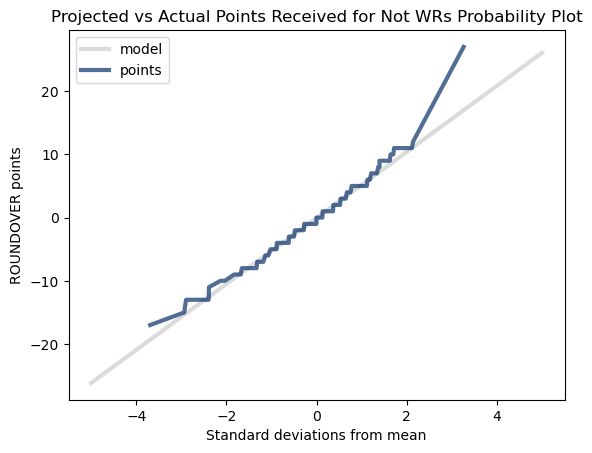

In [362]:
MakeNormalPlot(not_wr_roundover)
thinkplot.Config(
    title="Projected vs Actual Points Received for Not WRs Probability Plot",
    xlabel="Standard deviations from mean",
    ylabel="ROUNDOVER points",
    loc="upper left")

In [110]:
#scatterplots########################

In [260]:
proj_points = wr['ROUNDPROJ']
total_points = wr['ROUNDTOTAL']
point_diff = wr['ROUNDOVER']
total_yards = wr['TOTALYARDS']

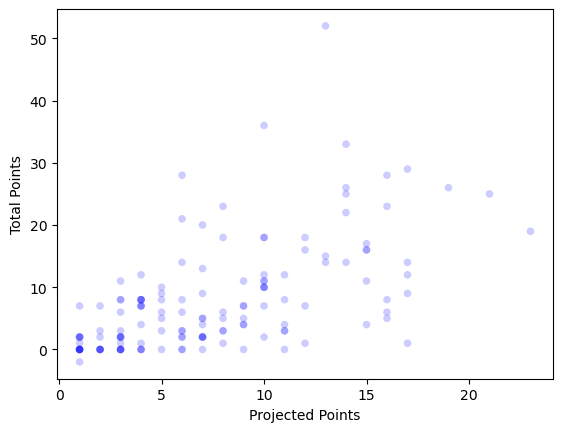

<Figure size 800x600 with 0 Axes>

In [262]:
thinkplot.Scatter(proj_points, total_points)
thinkplot.Show(xlabel='Projected Points',
               ylabel='Total Points')

In [264]:
#function to determine covariance
def Cov(xs, ys, meanx=None, meany=None):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if meanx is None:
        meanx = np.mean(xs)

    if meany is None:
        meany = np.mean(ys)

    cov = np.dot(xs-meanx, ys-meany) / len(xs)
    return cov

In [266]:
Cov(proj_points, total_points)

26.019387755102038

In [268]:
#function to determine Pearson's correlation
def Corr(xs, ys):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    meanx, varx = thinkstats2.MeanVar(xs)
    meany, vary = thinkstats2.MeanVar(ys)

    corr = Cov(xs, ys, meanx, meany) / math.sqrt(varx * vary)
    return corr

In [270]:
Corr(proj_points, total_points)

0.5836046552567039

In [272]:
#the number above shows that the relationship between projected and total points is potentially linear
#and the two values hace a fairly positive linear relationship

In [274]:
#########scatterplot number 2######

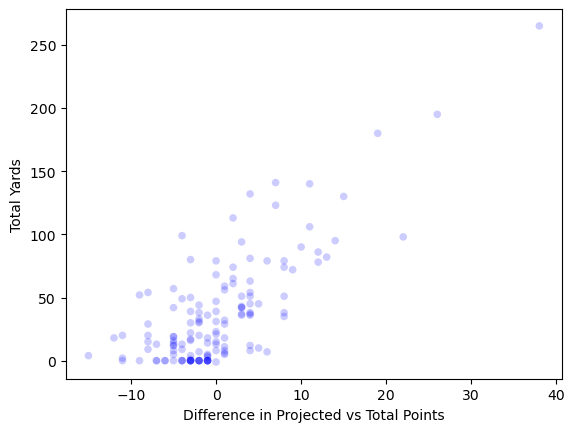

<Figure size 800x600 with 0 Axes>

In [276]:
thinkplot.Scatter(point_diff, total_yards)
thinkplot.Show(xlabel='Difference in Projected vs Total Points',
               ylabel='Total Yards')

In [278]:
Cov(point_diff, total_yards)

236.71556122448976

In [280]:
Corr(point_diff, total_yards)

0.7660791286170451

In [ ]:
################### HYPOTHESIS TESTING ######################

In [ ]:
#Null Hypothesis: There is no difference between Wide Receivers and other players,
#and both groups have the same distribution for the ROUNDOVER variable

In [290]:
#calculate difference in means
diff = np.mean(wr_roundover) - np.mean(not_wr_roundover)
diff

0.37723214285714285

In [332]:
#run a permuation test based on ROUNDOVER between WRs and Others
def permutation_test(wr_points, not_wr_points):
    #Combine both into one pool
    combined_points = np.concatenate([wr_points, not_wr_points])
    #initialize list
    perm_diffs = []
    
    #run 10000 permutations
    for _ in range(10000):
        np.random.shuffle(combined_points)
        
        # Split data back into two groups (same size as original groups)
        group1 = combined_points[:len(wr_points)]
        group2 = combined_points[len(wr_points):]
        
        # Calculate the difference in means for the 2 new groups
        group_diff = np.mean(group1) - np.mean(group2)
        #put values of means together into one list
        perm_diffs.append(group_diff)
    
    # Calculate the p-value: Proportion of permuted differences >= observed difference
    p_value = np.mean(np.array(perm_diffs) >= diff)
    
    return p_value

#Run the permutation test and get the p-value
p_value = permutation_test(wr_roundover, not_wr_roundover)
p_value

0.2963

In [ ]:
#the p value of around 0.3 means that we cannot reject the null hypothesis, and if wide receivers over-achieve on points
#it is due to random chance

In [ ]:
################### REGRESSION #############################

In [340]:
#linear regression
formula = 'ROUNDOVER ~ TOTALYARDS'
model = smf.ols(formula, data=wr)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              ROUNDOVER   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     196.0
Date:                Fri, 28 Feb 2025   Prob (F-statistic):           2.85e-28
Time:                        12:47:20   Log-Likelihood:                -411.24
No. Observations:                 140   AIC:                             826.5
Df Residuals:                     138   BIC:                             832.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.2826      0.512     -8.358      0.000      -5.296      -3.269
TOTALYARDS     0.1251      0.009     14.001      0.000       0.107       0.143
==============================================================================
Omnibus:                        3.003   Durbin-Watson:                   0.880
Prob(Omnibus):                  0.223   Jarque-Bera (JB):                2.478
Skew:                          -0.280   Prob(JB):                        0.290
Kurtosis:                       3.335   Cond. No.                         75.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#with the high f statistic, it shows that this model does a good job 
#explaining any variance in the ROUNDOVER variable
#The p value is most likely not exactly 0, but may be small enough to round to 0
#this means that the result is highly significant